/Users/kangyopchi/Firenodes/Projects/FIREgen


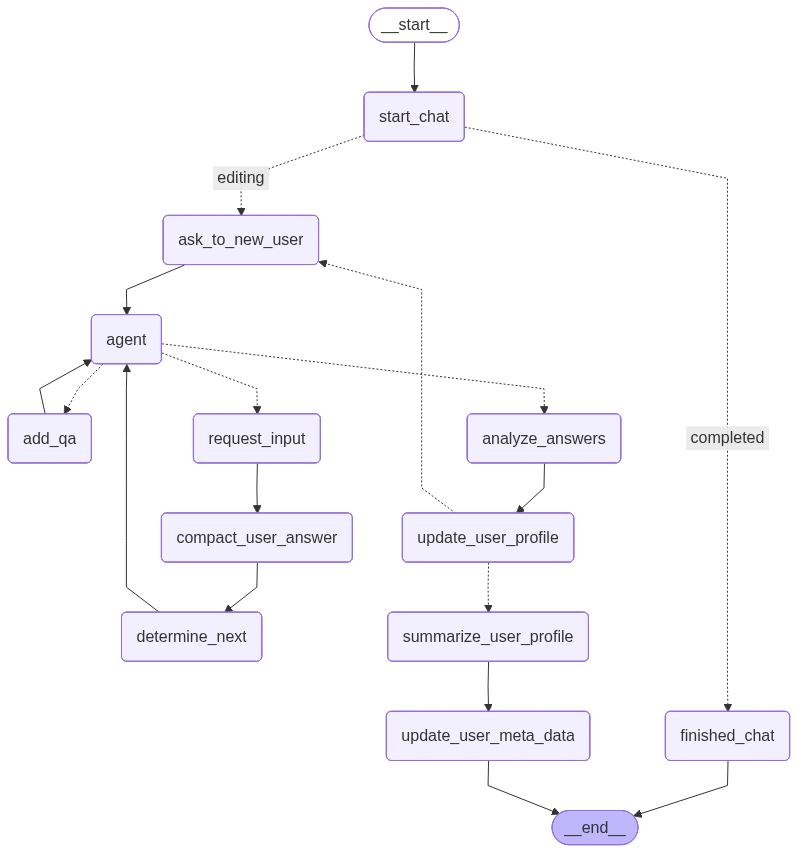

In [2]:
import sys
from pathlib import Path

from IPython.display import Image, display

project_root = Path.cwd().parents[2]
print(project_root)
sys.path.append(str(project_root))

try:
    from my_app.chatbot.chat_core.graph_builder import GraphBuilder
except ImportError:
    raise ImportError("GraphBuilder is not found")


builder = GraphBuilder()
graph = builder.build_workflow()


display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [2]:
from langchain_core.runnables import RunnableConfig

from my_app.chatbot.chat_core.state import InputState
from my_app.chatbot.services import MockProfileService

user_data = InputState(
    target_profile_category=[
        "investment_goal",
        "investment_emotions",
        "interests_categories",
        "investment_level",
        "knowledge_level",
        "risk_tolerance",
    ],
    user_meta_data={
        "name": "강요셉",
        "profile_status": "onboarding",
        "investment_goal": [],
        "investment_emotions": [],
        "interests_categories": [],
        "investment_level": [],
        "knowledge_level": [],
        "risk_tolerance": 0,
    },
)

config: RunnableConfig | None = {
    "configurable": {"thread_id": "1", "profile_service": MockProfileService()}
}

message_data = []
events = []

for event in graph.stream(user_data, config, stream_mode="values"):
    events.append(event)
    if "messages" in event:
        data = event["messages"]
        message_data.append(data)
        event["messages"][-1].pretty_print()

Creating new LLM client for gpt-5-mini
================================== Ai Message ==================================

안녕하세요, 강요셉님! 자산구조대입니다. 투자 여정을 함께 하게되어 기대됩니다. 잘 부탁드립니다.
================================ Human Message =================================


Ask the user predefined quiz sets.
Use the 'RequestHumanInput' tool to ask the user with predefined quiz sets.

Predefined quiz sets:
- Category: investment_goal
- Questions: ['귀하의 투자 경험에 대해 가장 잘 설명하는 것은 무엇인가요?', '투자를 통해 가장 중요하게 생각하는 목표는 무엇이며, 이를 위해 얼마나 오래 투자할 수 있나요?', '다음 중 귀하의 투자 성향에 가장 가까운 설명은 무엇인가요?']
- Options: [['투자 경험이 전혀 없습니다.', '주식, 채권 또는 뮤추얼 펀드에 대해 약간의 지식과 경험이 있습니다.', '다양한 유형의 투자에 대해 잘 알고 있으며 상당한 경험이 있습니다.', '저는 전문 투자자입니다.'], ['3년 이내의 단기간 동안 원금을 안전하게 보존하는 것이 최우선입니다.', '3년에서 5년 정도의 기간 동안 예금보다 약간 높은 수준의 안정적인 이자 수익을 원합니다.', '5년 이상의 장기적인 관점에서 시장 평균 수준전 수익률을 목표로 자산을 꾸준히 증식시키고 싶습니다.', '단기적인 손실을 감수하더라도 10년 이상의 장기 투자를 통해 시장 평균을 초과하는 높은 수익을 추구합니다.'], ['원금 손실은 절대 용납할 수 없습니다. 수익이 거의 없더라도 원금이 보장되는 것이 가장 중요합니다.', '약간의 원금 손실 위험은 감수할 수 

In [3]:
for message in message_data:
    for msg in message:
        msg.pretty_print()

================================== Ai Message ==================================

안녕하세요, 강요셉님! 자산구조대입니다. 투자 여정을 함께 하게되어 기대됩니다. 잘 부탁드립니다.
================================== Ai Message ==================================

강요셉님의 투자 목표를 알아볼까요? 투자 목표를 안다면, 투자 방향성과 전략을 명확히 설정하고, 감정적인 결정이나 혼란을 줄이며, 장기적으로 일관된 성과와 재정적 성공을 이루는 데 도움이 됩니다.
================================ Human Message =================================


Ask the user predefined quiz sets.
Use the 'RequestHumanInput' tool to ask the user with predefined quiz sets.

Predefined quiz sets:
- Category: investment_goal
- Questions: ['귀하의 투자 경험에 대해 가장 잘 설명하는 것은 무엇인가요?', '투자를 통해 가장 중요하게 생각하는 목표는 무엇이며, 이를 위해 얼마나 오래 투자할 수 있나요?', '다음 중 귀하의 투자 성향에 가장 가까운 설명은 무엇인가요?']
- Options: [['투자 경험이 전혀 없습니다.', '주식, 채권 또는 뮤추얼 펀드에 대해 약간의 지식과 경험이 있습니다.', '다양한 유형의 투자에 대해 잘 알고 있으며 상당한 경험이 있습니다.', '저는 전문 투자자입니다.'], ['3년 이내의 단기간 동안 원금을 안전하게 보존하는 것이 최우선입니다.', '3년에서 5년 정도의 기간 동안 예금보다 약간 높은 수준의 안정적인 이자 수익을 원합니다.', '5년 이상의 장기적인 관점에서 시장 평균 수준전 수익률을 목표로 자산을 꾸준히 증식시키고 

In [ ]:
message_data[-1].tool_calls[0]["args"]
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

print(questions)
print(options)

In [ ]:
import numpy as np

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

print(answers_set)

In [ ]:
from langgraph.types import Command

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
message_data_2nd[-1].tool_calls[0]["args"]
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

print(questions_2nd)
print(options_2nd)

In [ ]:
import numpy as np

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

print(answers_set_2nd)

In [ ]:
from langgraph.types import Command

message_data = []
last_message_id = None

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id


In [ ]:
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

message_data = []
last_message_id = None

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id

In [ ]:
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

message_data = []
last_message_id = None

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id

In [ ]:
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

message_data = []
last_message_id = None

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id

In [ ]:
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

message_data = []
last_message_id = None

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id

In [ ]:
questions = message_data[-1].tool_calls[0]["args"]["questions"]
options = message_data[-1].tool_calls[0]["args"]["options"]

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 3, replace=False)

answers_set = []
for i in range(len(questions)):
    answers_set.append((questions[i], options[i][random_numbers[i] - 1]))

message_data_2nd = []
last_message_id_2nd = None

for event in graph.stream(Command(resume=answers_set), config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id_2nd != current_message.id:
            message_data_2nd.append(current_message)
            current_message.pretty_print()
            last_message_id_2nd = current_message.id


In [ ]:
questions_2nd = message_data_2nd[-1].tool_calls[0]["args"]["questions"]
options_2nd = message_data_2nd[-1].tool_calls[0]["args"]["options"]

print(questions_2nd)
print(options_2nd)

np.random.seed(42)  # 시드값 고정
random_numbers = np.random.choice(range(1, 5), 2, replace=False)

answers_set_2nd = []
for i in range(len(questions_2nd)):
    answers_set_2nd.append((questions_2nd[i], options_2nd[i][random_numbers[i] - 1]))

message_data = []
last_message_id = None

events = []

for event in graph.stream(
    Command(resume=answers_set_2nd), config, stream_mode="values"
):
    events.append(event)
    if "messages" in event and event["messages"]:
        current_message = event["messages"][-1]

        # 현재 메시지가 이전에 출력한 메시지와 다를 경우에만 출력
        if last_message_id != current_message.id:
            message_data.append(current_message)
            current_message.pretty_print()
            last_message_id = current_message.id

In [ ]:
events[-1]